<style>
    .jp-RenderedHTMLCommon {
        font-family: "Times New Roman", Times, serif !important;
        font-size: 14px !important;
    }
</style>

### Лабораторная работа №1

Вариант 7

### **1. Постановка задачи**

Найти корень нелинейного уравнения
$$f(x) = 2\ln(x) - \frac{1}{x} = 0$$
применяя следующие методы:

1. Метод простой итерации
2. Метод Ньютона
3. Метод Стеффенсена

Необходимо:
1. Отделить хотя бы один (если их несколько) корень уравнения графическим способом.
2. Выбрать начальное приближение $x_0$, исходя из выполнения условий теоремы о сходимости метода простой итерации.
3. Используя выбранное начальное приближение $x_0$, найти тремя вышеуказанными методами решение данного нелинейного уравнения с точностью $\varepsilon = 10^{-7}$. Критерием останова итерационного процесса выбрать следующий: $\left| x^{k+1} - x^k\right| \le \varepsilon$.
4. Сравнить методы по скорости сходимости (теоретически и практически) и
точности (оценить величину невязки каждого метода).

### **2. Отделить хотя бы один (если их несколько) корень уравнения графическим способом.**

Построим график функции $f(x)$:

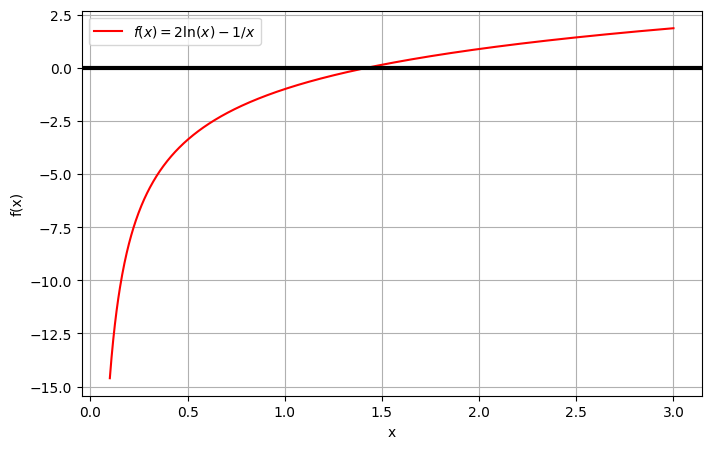

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x: float) -> float: 
    return 2*np.log(x) - 1/x

x = np.linspace(0.1, 3, 1000)
y = [f(xi) for xi in x]

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$f(x) = 2 \ln(x) - 1/x$', color='red')
plt.axhline(0, color='black', linewidth=3)  
plt.grid(True)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

Выделим интервал $[1.25; 1.75]$, в котором находится корень уравнения.

### **3. Выбрать начальное приближение $x_0$, исходя из выполнения условий теоремы о сходимости метода простой итерации.**

Пусть $x = \varphi(x)$ - канонический вид уравнения.    (1) 

$x^{k+1} = \varphi(x^k), \quad k = 0, 1, 2 \qquad (2)$ 

где $x^k$ — последовательность, начинающаяся с $x^0$, которая должна сходится к точному
решению.

**Теорема** (о сходимости метода простой итерации).

*Пусть выполняются следующие условия:*

1. *функция $\varphi(x)$ определена на отрезке $$\left| x - x_0 \right| \le \delta$$ непрерывна на нем и удовлетворяет условию Липшица с постоянным коэффициентом меньше единицы, то есть $\forall x, \tilde{x} \qquad (3)$*
$$\left|\varphi(x) - \varphi(\tilde{x})\right| \le q\left|x-\tilde{x}\right|, \quad 0 \le q < 1; \qquad (4)$$

2. *для начального приближения $x_0$ верно неравенство*
$$\left|x^0 - \varphi(x^0)\right| \le m;$$

3. *числа $\delta, q, m$ удовлетворяют условию*
$$\frac{m}{1-q} \le \delta \qquad (5)$$

Тогда
1. *уравнение (1) в области (3) имеет решение;* 

2. *последовательность $x^k$, построенная по правилу (2), принадлежит отрезку $[x^0- \delta, x^0 + \delta]$, является сходящейся, и ее предел удовлетворяет уравнению (1):*
$$x_k \to x^*, \quad k \to \infty$$

3. *скорость сходимости последовательности $x^k$ к ее пределу $x^*$ оценивается неравенством*
$$\left|x^* - x^k\right| \le \frac{m}{1-q}q^k, \quad k = 1, 2, ... \qquad (6)$$

**Замечание.**

1. Для построения сходящегося метода простой итерации в практических вычислениях первое условие теоремы о сходимости метода простой итерации обычно заменяется более строгим требованием, а именно для всех $x$ из отрезка $\left|x - x^0\right| \le \delta$ функция $\varphi(x)$ имеет непрерывную первую производную $\varphi'(x)$ такую, что $$\left|\varphi'(x)\right| < 1 \quad \forall x \in [x^0 - \delta; x^0 + \delta]$$

---

В качестве $x^0$ возьмем значение $x^0 = 1.5$. Тогда $\delta = 0.25$

Приведём уравнение к виду $x = \varphi(x)$:
$$x = e^{\frac{1}{2x}}, \quad \varphi(x) = e^{\frac{1}{2x}}$$

Тогда
$$\varphi'(x) = -\frac{e^{\frac{1}{2x}}}{2x^2}$$

Функция $\left|\varphi'(x)\right|$ убывает при увеличении $x$, следовательно, максимум достигается в левой границе интервала $[x^0 - \delta; x^0 + \delta]$:
$$\left|\varphi'(1.25)\right| \approx 0.477 < 1$$

Следовательно, $\left|\varphi'(x)\right| < 1 \quad \forall x \in [1.25, 1.75]$. 

Найдем $m$ и $q$:

In [7]:
def phi(x: float) -> float:
    return np.exp((1/(2*x)))

def phi_derivative(x: float) -> float:
    return -1 * (np.exp(1/2*x)) / (2*x**2)

x0 = 1.5
delta = 0.25
a = 1.25
b = 1.75

m = abs(phi(x0) - x0)

x = np.linspace(a,b,1000)
#q = np.max([abs(phi_derivative(xi)) for xi in x])

q = 1 - m / delta
print(f"m = {m}")
print(f"q = {q}")



if m/(1-q) <= delta: 
    print("m, q, delta удовлетворяют условию теоремы.")
else:
    print("m, q, delta не удовлетворяют условию теоремы.")

m = 0.10438757491391049
q = 0.5824497003443581
m, q, delta удовлетворяют условию теоремы.


Условия теоремы выполняются, следовательно, в качестве начального приближения возьмем $x^0 = 1.5$.

### **3. Используя выбранное начальное приближение $x_0$, найти тремя вышеуказанными методами решение данного нелинейного уравнения с точностью $\varepsilon = 10^{-7}$. Критерием останова итерационного процесса выбрать следующий: $\left| x^{k+1} - x^k\right| \le \varepsilon$.**

#### **3.1 Метод простых итераций**

Метод простой итерации заключается в приведении исходного уравнения к виду
$$x = \varphi(x)$$
и построении последовательности
$$x^{k+1} = \varphi(x^k)$$

При выполнении условия сходимости последовательность $x^k$ сходится к корню уравнения $x^* = \varphi(x^*)$.

In [12]:
EPS = 1e-7

def fixed_point_iteration(x0: float, phi: callable, EPS: float) -> tuple:
    "Возвращает приближенное решение уравнения x = phi(x) и количество итераций."
    x_prev = x0
    x_new = 0
    counter = 0

    while True:
        x_new = phi(x_prev)
        counter += 1
        if abs(x_new - x_prev) <= EPS:
            break
        x_prev = x_new
    return x_new, counter

solution, iterations = fixed_point_iteration(x0, phi, EPS)
print(f"Приближенное решение, полученное методом простых итераций: {solution}")
print(f"Количество итераций: {iterations}")
print(f"Невязка: {f(solution)}")

Приближенное решение, полученное методом простых итераций: 1.4215299242007566
Количество итераций: 15
Невязка: -2.2217527040346852e-08


#### **3.2 Метод Ньютона**

Метод Ньютона (метод касательных) заключается в построении последовательности приближений к корню уравнения $f(x) = 0$ по формуле
$$x^{k+1} = x^k - \frac{f(x^k)}{f'(x^k)}$$

где производная $f(x)$ имеет вид:
$$f'(x) = \frac{2}{x} + \frac{1}{x^2} = \frac{2x+1}{x^2}$$

In [ ]:
def f_derivative(x: float) -> float: 
    return 2/x + 1/x**2

def newton_method(x0: float, f: callable, f_derivative: callable, EPS: float) -> tuple:
    "Возвращает приближенное решение уравнения f(x) = 0 и количество итераций."
    x_prev = x0
    x_new = 0
    counter = 0

    while True: 
        x_new = x_prev - f(x_prev)/f_derivative(x_prev)
        counter += 1
        if abs(x_new - x_prev) <= EPS:
            break
        x_prev = x_new
    return x_new, counter

solution, iterations = newton_method(x0, f, f_derivative, EPS)
print(f"Приближенное решение, полученное методом Ньютона: {solution}")
print(f"Количество итераций: {iterations}")
print(f"Невязка: {f(solution)}")

Приближенное решение, полученное методом Ньютона: 1.4215299358831166
Количество итераций: 4
Невязка: 0.0


#### **3.3 Метод Стеффенсeна**

